# Confronto tra AlphaFold e dati sperimentali: analisi del Fold-Switching in RfaH


**Il razionale biologico**

La proteina **RfaH** è un importante fattore di regolazione batterico che controlla la trascrizione genica. RfaH è un'esempio paradigmatico di proteina metamorfica che presenta due possibili conformazioni:
1) **Stato autoinibito** (Off): Quando la proteina è libera nel citoplasma il dominio C-terminale (CTD) è ripiegato come un'alpha-elica e copre il sito attivo.
2) **Stato attivo** (On): Quando la proteina si lega all'RNA polimerasi il CTD si srotolla e si ripiega completamente in un barile-beta determinandone lo stato attivo (che dà al microrganismo la capacità di infettare e causare malattie) [1]


---



**Predizioni strutturali tramite AlphaFold e metriche di confidenza (pLDDT)**

Il limite intrinseco degli attuali modelli di deep learning come AlphaFold è la loro tendenza a convergere verso un unico minimo energetico globale, spesso corrispondente alla conformazione più stabile (efficace per la maggior parte delle proteine globulari a singolo dominio). Questo approccio infatti fallisce con le proteine metamorfiche in grado di cambiare conformazione come RfaH [2] [3].
AlphaFold fornisce una propria metrica di confidenza: il pLDDT (predicted Local Distance Difference Test) è un punteggio per residuo su una scala da 0 a 100 che stima la concordanza locale tra la predizione e la struttura reale.

*N.B. AlphaFold fornisce un pLDDT globale ma memorizza il punteggio pLDDT per singolo residuo nella colonna dei file PDB solitamente destinata ai B-factor.*


---


**Obiettivo del progetto**: L'obiettivo è sviluppare uno script Python che confronti le predizioni di AlphaFold con le strutture sperimentali (PDB) di RfaH. L'obiettivo non è solo calcolare l'errore globale, ma mappare l'errore locale (per residuo) contro la confidenza del modello (pLDDT per residuo) per determinare se l'IA è "consapevole" della propria incertezza nelle regioni metamorfiche o se "allucina" una struttura stabile errata con alta confidenza.

---
**Fondamenti algoritmici: Sovrapposizione e RMSD**

**Sovrapposizione (Superposition)**:
Quando ho due proteine nello spazio 3D, non posso semplicemente calcolare la distanza tra i loro atomi. Anche se sono identiche, potrebbero trovarsi in posizioni diverse o essere ruotate diversamente (sistema di riferimento differente), visto che i dati saranno acquisiti da due banche dati differenti (AlphaFold e RCBS). Per confrontarle, devo prima sovrapporle (superimpose) in modo ottimale.

L'algoritmo che utilizzerò nel codice a seguire (Bio.PDB.Superimposer) si basa sul metodo di Kabsch, che utilizza la decomposizione ai valori singolari (SVD) per trovare la matrice di rotazione ottimale [4] [5].


**RMSD (Root Mean Square Deviation - Deviazione Quadrata Media)**

Una volta che le proteine sono sovrapposte (ruotate per combaciare il più possibile), bisogna quantificare quanto sono diverse. L'RMSD (Root Mean Square Deviation) è la media quadratica delle distanze tra atomi corrispondenti.

Dati $N$ atomi corrispondenti (in questo caso i Carboni-Alfa di residui allineati), l'RMSD è:$$RMSD = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \delta_i^2}$$Dove: $\delta_i$ = Distanza Euclidea tra l'atomo $i$ della struttura A e l'atomo $i$ della struttura B (dopo la sovrapposizione).$$\delta_i = \sqrt{(x_{A,i}-x_{B,i})^2 + (y_{A,i}-y_{B,i})^2 + (z_{A,i}-z_{B,i})^2}$$



---

**Interpretazione dei risultati**
Il calcolo degli RMSD genererà un vettore di "errori locali" per i singoli residui. Parallelamente avrò per gli stessi residui il vettore delle confidenze pLDDT generate da AlphaFold. L'obiettivo è mostrare come nella regione terminale metamorfica la confidenza dell'IA (pLDDT) rimane alta a fronte di un errore locale alto ("allucinazione").

---

**Riferimenti Bibliografici:**

[1] *Burmann BM, Knauer SH, Sevostyanova A, Schweimer K, Mooney RA, Landick R, Artsimovitch I, Rösch P. An α helix to β barrel domain switch transforms the transcription factor RfaH into a translation factor. Cell. 2012 Jul 20;150(2):291-303. doi: 10.1016/j.cell.2012.05.042. PMID: 22817892; PMCID: PMC3430373.*

[2] *Chakravarty D, Porter LL. AlphaFold2 fails to predict protein fold switching. Protein Sci. 2022 Jun;31(6):e4353. doi: 10.1002/pro.4353. PMID: 35634782; PMCID: PMC9134877.*

[3] *Chakravarty, D., Schafer, J.W., Chen, E.A. et al. AlphaFold predictions of fold-switched conformations are driven by structure memorization. Nat Commun 15, 7296 (2024). https://doi.org/10.1038/s41467-024-51801-z*

[4] https://biopython.org/docs/1.75/api/Bio.PDB.Superimposer.html

[5] https://warwick.ac.uk/fac/sci/moac/people/students/peter_cock/python/protein_superposition/

# Download e importazione dei dati

File PDB scaricati:
1) Predizione di RfaH dal sito di AlphaFold DB cercando P0AFW0 (RfaH) --> 'predizione.pdb'
2) La proteina autoinibita (alfa-eliche) dalla banca dati RCBS PDB cercando 2OUG --> 'autoinibito.pdb'
3) La proteina nello stato attivo (barili-beta) sempre dalla banca dati RCBS PDB cercando 6C6S --> 'attivo.pdb'

Importiamo i file PDB dalla cartella esterna.

In [1]:
from google.colab import files
import os

print("Carica i file: 'predizione.pdb', 'autoinibito.pdb', 'attivo.pdb'")
uploaded = files.upload()

# Verifica che i file siano stati caricati
required_files = ['predizione.pdb', 'autoinibito.pdb', 'attivo.pdb']
missing_files = [f for f in required_files if f not in uploaded]

if missing_files:
    print(f"ATTENZIONE: Mancano i seguenti file: {missing_files}")
else:
    print("Tutti i file sono stati caricati correttamente")

Carica i file: 'predizione.pdb', 'autoinibito.pdb', 'attivo.pdb'


Saving attivo.pdb to attivo.pdb
Saving autoinibito.pdb to autoinibito.pdb
Saving predizione.pdb to predizione.pdb
Tutti i file sono stati caricati correttamente


# **Installazione delle librerie**
Installazione della libreria *Biopython* per i calcoli biologici, e *py3Dmol* per la visualizzazione molecolare 3D interattiva delle proteine.



In [2]:
!pip install biopython py3Dmol matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.9 MB/s eta 0:00:00


# Sovrapposizione, calcolo del RMDS e grafico

Parsing dei file PDB...


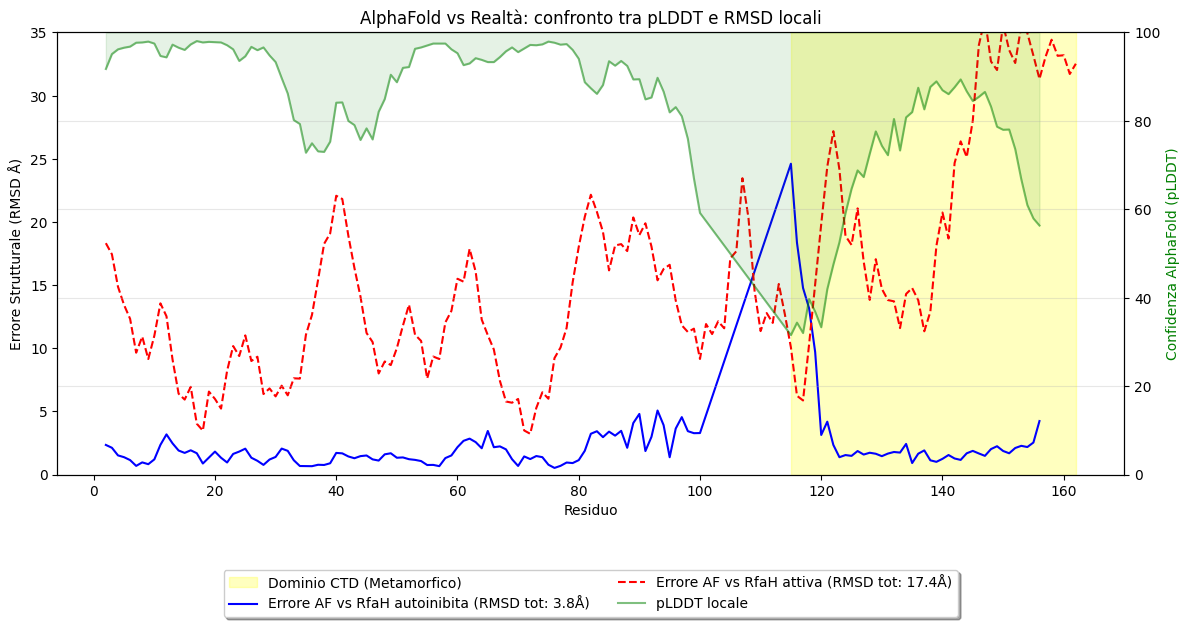

In [7]:
import Bio.PDB
import numpy as np
import matplotlib.pyplot as plt


# FUNZIONI UTILI

def extract_chain(structure, chain_id=None):
    """Estrae i residui C-alfa da una struttura/catena specifica."""
    residues = []
    # Assumendo che la maggior parte dei file PDB abbiano perlomeno un modello (e che il
    # modello con ID 0 sia quello di interesse)
    model = structure[0]

    if chain_id:
        chain = model[chain_id]
        chains_to_scan = [chain]
    else:
        # Se non esiste uno specifico chain_id, itera lungo tutte le catene presenti nel modello
        chains_to_scan = model.get_chains()

    for chain in chains_to_scan:
        for res in chain:
            if Bio.PDB.is_aa(res) and 'CA' in res:
              # controlla sia che il resiuduo sia un amminoacido standard (escludendo molecole d'acqua ecc.)
              # sia che il residuo contenga un atomo chiamato 'CA' (carbonio-alfa)
                residues.append(res)
    return residues

def align_and_calculate_RMSD(target_res, model_res, model_structure):
    """
    Allinea le strutture e calcola RMSD locale e pLDDT.
    Restituisce anche la struttura ruotata per la visualizzazione 3D.
    """
    # 1. Filtra le strutture per trovare i residui corrispondenti, estrae i loro atomi C-alfa per l'allineamento
    # e raccoglie i punteggi di confidenza pLDDTper l'analisi successiva.

    # Target ---> struttura sperimentale
    # Model ---> struttura AlphaFold


    # Crea due dizionari per le strutture (target e model). Ogni residuo della proteina viene inserito
    # nel dizionario con il suo numero identificativo (ID) come chiave così da rendere facile accedere ai singoli
    # residui specifici usando il suo ID
    target_dictionary = {r.id[1]: r for r in target_res} #target --> struttura sperimentale
    model_dictionary = {r.id[1]: r for r in model_res} # model --> struttura AlphaFold

    # Trova i residui comuni alle due proteine e li ordina numericamente
    common_ids = sorted(list(set(target_dictionary.keys()) & set(model_dictionary.keys())))

    target_CA_atoms = []
    model_CA_atoms = []
    plddt_values = []
    residues_numbers = []

    #estrae i CA e i pLDDT
    for rid in common_ids:
        target_CA_atoms.append(target_dictionary[rid]['CA'])
        model_CA_atoms.append(model_dictionary[rid]['CA'])
        # pLDDT è nel B-factor del file AlphaFold
        plddt_values.append(model_dictionary[rid]['CA'].get_bfactor())
        residues_numbers.append(rid)

    # 2. Sovrapposizione (SVD)
    super_imposer = Bio.PDB.Superimposer()
    super_imposer.set_atoms(target_CA_atoms, model_CA_atoms)

    # Applica la rotazione all'INTERA struttura AlphaFold (non solo agli atomi comuni)
    # Questo modifica l'oggetto 'model_structure' in memoria per la visualizzazione 3D successiva
    super_imposer.apply(model_structure.get_atoms())

    # 3. Calcolo RMSD Locale
    local_rmsd = []
    for i in range(len(target_CA_atoms)):
        diff = target_CA_atoms[i].coord - model_CA_atoms[i].coord
        dist = np.sqrt(np.sum(diff * diff))
        local_rmsd.append(dist)

    return residues_numbers, local_rmsd, plddt_values, super_imposer.rms

# ESECUZIONE

# 'True' dice al parser di sopprimere i messaggi di avviso legati a piccole imperfezioni nei dati
parser = Bio.PDB.PDBParser(QUIET=True)

# 1. Caricamento Strutture (dai file locali caricati)
print("Parsing dei file PDB...")
structure_AF_1 = parser.get_structure("AF1", "predizione.pdb") # Copia per confronto 1
structure_AF_2 = parser.get_structure("AF2", "predizione.pdb") # Copia per confronto 2

structure_off = parser.get_structure("OFF", "autoinibito.pdb")
structure_on = parser.get_structure("ON", "attivo.pdb")

# 2. Selezione Catene (RfaH è catena A in 2OUG, catena D in 6C6S)
residues_AF_1 = extract_chain(structure_AF_1)
residues_AF_2 = extract_chain(structure_AF_2)
residues_off = extract_chain(structure_off, chain_id="A")
residues_on = extract_chain(structure_on, chain_id="D")

# 3. Calcoli
x1, rmsd1, plddt1, global_rmsd_1 = align_and_calculate_RMSD(residues_off, residues_AF_1, structure_AF_1)
x2, rmsd2, plddt2, global_rmsd_2 = align_and_calculate_RMSD(residues_on, residues_AF_2, structure_AF_2)

# 4. Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Evidenzia dominio CTD metamorfico
ax1.axvspan(115, 162, color='yellow', alpha=0.25, label='Dominio CTD (Metamorfico)')

ax1.set_xlabel('Residuo')
ax1.set_ylabel('Errore Strutturale (RMSD Å)', color='black')
ax1.plot(x1, rmsd1, color='blue', label=f'Errore AF vs RfaH autoinibita (RMSD tot: {global_rmsd_1:.1f}Å)')
ax1.plot(x2, rmsd2, color='red', linestyle='--', label=f'Errore AF vs RfaH attiva (RMSD tot: {global_rmsd_2:.1f}Å)')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, 35)

ax2 = ax1.twinx()
ax2.set_ylabel('Confidenza AlphaFold (pLDDT)', color='green')
ax2.plot(x1, plddt1, color='green', alpha=0.5, label='pLDDT locale')
ax2.fill_between(x1, plddt1, 100, color='green', alpha=0.1)
ax2.set_ylim(0, 100)

plt.title('AlphaFold vs Realtà: confronto tra pLDDT e RMSD locali')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

Area evidenziata in giallo (Dominio CTD Metamorfico): Questa regione (residui 115-162) è stata evidenziata perché è nota per essere un dominio metamorfico, ovvero una parte della proteina che può assumere diverse conformazioni.

# Interpretazione dei risultati

Dal grafico confrontando i risultati ottenuti nella regione metamorfica CTD si può evincere che:

1) per quanto riguarda la predizione dello stato autoinibito della proteina AlphaFold commette un errore basso, che è un risultato coerente con il punteggio di autovalutazione pLDDT alto

2) al contrario AlphaFold commette un errore di bias cognitivo per quanto riguarda la predizione dello stato attivo, con un errore locale RMSD alto a fronte di un punteggio pLDDT che rimane alto (crede di essere "sicuro" della sua predizione)

In sintesi, il grafico mostra sia che la predizione di AlphaFold è più simile allo stato autoinibito della proteina, "ignorando" lo stato attivo della stessa.

# Visualizzazione 3D

In [5]:
!pip install py3Dmol
import py3Dmol
from Bio.PDB import PDBIO
from io import StringIO

def show_structure_comparison(target_struct, target_chain_id, aligned_af_struct, title, af_color='cyan'):
    view = py3Dmol.view(width=800, height=400)

    io = PDBIO()
    # Selezione solo della catena di interesse per pulizia
    class ChainSelect(Bio.PDB.Select):
        def accept_chain(self, chain):
            return chain.get_id() == target_chain_id

    io.set_structure(target_struct)
    str_io_target = StringIO()
    io.save(str_io_target, select=ChainSelect())
    pdb_str_target = str_io_target.getvalue()

    view.addModel(pdb_str_target, 'pdb')
    view.setStyle({'model': 0}, {'cartoon': {'color': 'lightgray', 'opacity':0.8}})
    view.addLabel("Sperimentale", {'position': {'x':0, 'y':0, 'z':0}, 'backgroundColor': 'lightgray', 'fontColor': 'black'})

    io.set_structure(aligned_af_struct)
    str_io_af = StringIO()
    io.save(str_io_af)
    pdb_str_af = str_io_af.getvalue()

    view.addModel(pdb_str_af, 'pdb')
    view.setStyle({'model': 1}, {'cartoon': {'color': af_color}})
    view.addLabel("AlphaFold", {'position': {'x':5, 'y':5, 'z':5}, 'backgroundColor': af_color, 'fontColor': 'black'})

    view.zoomTo()
    print(f"--- {title} ---")
    view.show()

show_structure_comparison(structure_off, "A", structure_AF_1, "Confronto 1: AlphaFold (Ciano) vs RfaH autoinibita (Grigio)", af_color='cyan')
print("\n")
show_structure_comparison(structure_on, "D", structure_AF_2, "Confronto 2: AlphaFold (Rosso) vs RfaH attiva (Grigio)", af_color='red')

--- Confronto 1: AlphaFold (Ciano) vs RfaH autoinibita (Grigio) ---


3Dmol.js failed to load for some reason. Please check your browser console for error messages.



--- Confronto 2: AlphaFold (Rosso) vs RfaH attiva (Grigio) ---


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

*Autore:* Alessandro Carbone

*Matricola*: 565219